# Steane Circ Level Noise (Multi round threshold)

Data generation and analysis
+ different decoder: ML, MWPM
+ different observables: Z,X
+ different distances
+ different noise levels
+ multiple rounds

analysis: 
+ determine thresholds depended on number of rounds


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import write_config, smart_read_folder
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

## Config Defintions and Data Generation

Steane circ (order 0p) with multiple QEC rounds (both log X and Z observable)

Circ noise with different noise levels

Decoding both in ML and MWPM


In [2]:
# General parameter
expected_p_th_log = -1.7
width = 0.5
noise_rates = [float(x) for x in np.logspace(expected_p_th_log - width , expected_p_th_log + width,dtype=float)]
distances = [3,5,7,9,]
qec_rounds = [1,2,3,4,6,8,10]
order = "0p"
circuit_type = "steane"
noise_model_type = "circ"

# Main parameters
# ml
num_shots_ML = 1_000 # 20 min
decoder_type_ML = "ml"
# mwpm
num_shots_MWPM = 10_000
decoder_type_MWPM = "mwpm"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [3]:
# Folder names (for writing data to file):
general_name = "md_mr_mp_MR"

In [4]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [5]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
config_path = write_config(config_ML_Z, general_name, backup=True, sub_name="ML_Z")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [6]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_ML_X, general_name, backup=True, sub_name="ML_X")

# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)


In [7]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
config_path = write_config(config_MWPM_Z, general_name, backup=True, sub_name="MWPM_Z")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

In [8]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
config_path = write_config(config_MWPM_X, general_name, backup=True, sub_name="MWPM_X")

# Generate ML Data
if regen_data_everything or regen_data_MWPM or False:
    generate_new_data_from_config_file(config_path, output_folder_name = general_name)

# Analysis 

In [9]:
# Folder paths (reading in data)
r_folder_path_ML_Z = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/ml/z/md_1r_mp_MR"
r_folder_path_ML_X = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/ml/x/md_1r_mp_MR"
r_folder_path_MWPM_Z = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/mwpm/z/md_1r_mp_MR"
r_folder_path_MWPM_X = "/home/fu494742/MasterArbeit/code/data/steane/0p/circ/mwpm/x/md_1r_mp_MR"

In [10]:
def analysis_pipeline(
        folder_path, 
        guess_pth, 
        guess_nu, 
        min_distance: list = None, 
        max_distance: list = None,
        min_noise_rate: list = None,
        max_noise_rate: list = None,
        p_window: float = None,
        plots = False,
        ):

    if p_window != None:
        if min_noise_rate != None or max_noise_rate != None:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window
        max_noise_rate = np.array(guess_pth) * p_window

    config, data = smart_read_folder(folder_path=folder_path)
    print(data["num_shots"])
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        max_distance=max_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            max_distance=max_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data

### Generate analysis Data

In [11]:
# General fit parameters: 
g_pth_ml_Z = [0.028, 0.022, 0.021, 0.020, 0.020, 0.020, 0.020,] 
g_pth_ml_X = [0.033, 0.023, 0.021, 0.020, 0.020,  0.021, 0.020,] 
g_pth_mwpm_Z = [0.026, 0.020, 0.019, 0.019, 0.019, 0.019, 0.019,]
g_pth_mwpm_X = [0.026, 0.020, 0.0195, 0.0195, 0.0195, 0.0195, 0.0195,] 

g_nu = [1.5] * len(qec_rounds)

p_window = 10**(0.15)
min_distance = [5] * len(qec_rounds)

In [12]:
folder_path = r_folder_path_ML_Z
g_pth = g_pth_ml_Z

result = analysis_pipeline(
    folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_Z = result

100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.8509842593303284
             x: [ 2.846e-02  6.909e-01]
           nit: 33
          nfev: 62
 final_simplex: (array([[ 2.846e-02,  6.909e-01],
                       [ 2.846e-02,  6.910e-01],
                       [ 2.846e-02,  6.910e-01]]), array([ 8.510e-01,  8.510e-01,  8.510e-01]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.6954061326989076
             x: [ 2.233e-02  6.956e-01]
           nit: 34
          nfev: 63
 final_simplex: (array([[ 2.233e-02,  6.956e-01],
                       [ 2.233e-02,  6.956e-01],
                       [ 2.233e-02,  6.956e-01]]), array([ 1.695e+00,  1.695e+00,  1.695e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.3206570421040624
             x: [ 2.122e-02  6.805e-01]
           nit: 38
 

In [13]:
folder_path = r_folder_path_ML_X 
g_pth = g_pth_ml_X

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_X = result

100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.0264142752055103
             x: [ 3.234e-02  7.325e-01]
           nit: 32
          nfev: 63
 final_simplex: (array([[ 3.234e-02,  7.325e-01],
                       [ 3.234e-02,  7.325e-01],
                       [ 3.234e-02,  7.325e-01]]), array([ 2.026e+00,  2.026e+00,  2.026e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.13347562147858
             x: [ 2.275e-02  6.737e-01]
           nit: 31
          nfev: 59
 final_simplex: (array([[ 2.275e-02,  6.737e-01],
                       [ 2.275e-02,  6.737e-01],
                       [ 2.275e-02,  6.737e-01]]), array([ 2.133e+00,  2.133e+00,  2.133e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.6014903538825216
             x: [ 2.128e-02  6.582e-01]
           nit: 30
   

In [14]:
folder_path = r_folder_path_MWPM_Z 
g_pth = g_pth_mwpm_Z

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result

100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.9138821520473785
             x: [ 2.649e-02  7.119e-01]
           nit: 36
          nfev: 69
 final_simplex: (array([[ 2.649e-02,  7.119e-01],
                       [ 2.649e-02,  7.119e-01],
                       [ 2.649e-02,  7.119e-01]]), array([ 1.914e+00,  1.914e+00,  1.914e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.6353217357385756
             x: [ 2.101e-02  6.725e-01]
           nit: 29
          nfev: 57
 final_simplex: (array([[ 2.101e-02,  6.725e-01],
                       [ 2.101e-02,  6.725e-01],
                       [ 2.101e-02,  6.725e-01]]), array([ 1.635e+00,  1.635e+00,  1.635e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9322256869903676
             x: [ 1.978e-02  7.066e-01]
           nit: 29
 

In [15]:
folder_path = r_folder_path_MWPM_X 
g_pth = g_pth_mwpm_X 

result = analysis_pipeline(
    folder_path = folder_path,
    guess_pth = g_pth,
    guess_nu = g_nu,
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

100000

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.3204093834615143
             x: [ 3.185e-02  6.449e-01]
           nit: 42
          nfev: 81
 final_simplex: (array([[ 3.185e-02,  6.449e-01],
                       [ 3.185e-02,  6.449e-01],
                       [ 3.185e-02,  6.449e-01]]), array([ 1.320e+00,  1.320e+00,  1.320e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.4028291289217734
             x: [ 2.191e-02  6.282e-01]
           nit: 63
          nfev: 118
 final_simplex: (array([[ 2.191e-02,  6.282e-01],
                       [ 2.191e-02,  6.282e-01],
                       [ 2.191e-02,  6.282e-01]]), array([ 1.403e+00,  1.403e+00,  1.403e+00]))

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.2696705542700104
             x: [ 2.060e-02  6.531e-01]
           nit: 31


In [16]:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]
for i in range(len(results)):
    print(f"{names[i]}: num_shots = {results[i]["num_shots"]/10**3}k")

ML Z: num_shots = 100.0k
ML X: num_shots = 100.0k
MWPM Z: num_shots = 100.0k
MWPM X: num_shots = 100.0k


## Results

In [26]:
from tools.parameter import PATH_TO_IMAGE_FOLDER

<Figure size 640x480 with 0 Axes>

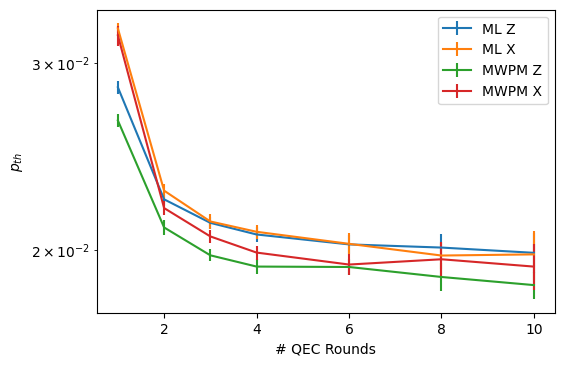

In [30]:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

plt.figure()
cm = 1/2.54 # to convert inches to cm
plt.subplots(figsize=(15*cm,10*cm))
for i in range(len(results)): 
    p_th = results[i]["p_th"]
    err_p_th = results[i]["err_p_th"]
    plt.errorbar(qec_rounds, p_th, yerr=err_p_th,label=names[i])
plt.xlabel("# QEC Rounds")
plt.ylabel("$p_{th}$")
plt.legend()
plt.yscale("log")
plt.savefig(PATH_TO_IMAGE_FOLDER+"/"+ "multi_round_all_log"+".pdf") 
plt.show()


<Figure size 640x480 with 0 Axes>

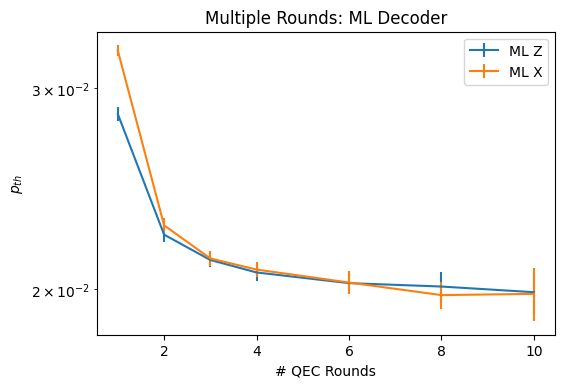

In [32]:
results = [results_ML_Z, results_ML_X, ]
names = ["ML Z", "ML X",]

plt.figure()
cm = 1/2.54 # to convert inches to cm
plt.subplots(figsize=(15*cm,10*cm))
plt.title("Multiple Rounds: ML Decoder")
for i in range(len(results)): 
    p_th = results[i]["p_th"]
    err_p_th = results[i]["err_p_th"]
    plt.errorbar(qec_rounds, p_th, yerr=err_p_th,label=names[i])
plt.xlabel("# QEC Rounds")
plt.ylabel("$p_{th}$")
plt.legend()
plt.yscale("log")
plt.savefig(PATH_TO_IMAGE_FOLDER+"/"+ "multi_round_ML_log"+".pdf") 
plt.show()

<Figure size 640x480 with 0 Axes>

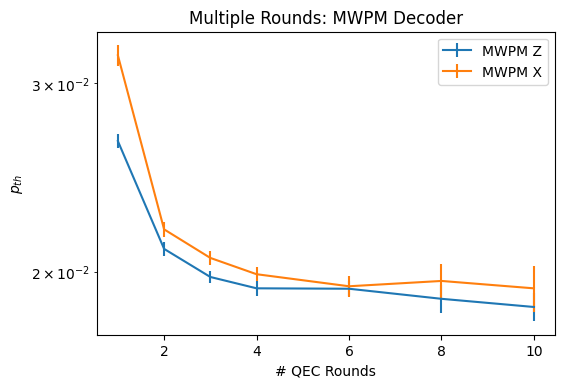

In [33]:
results = [results_MWPM_Z, results_MWPM_X]
names = ["MWPM Z", "MWPM X"]

plt.figure()
cm = 1/2.54 # to convert inches to cm
plt.subplots(figsize=(15*cm,10*cm))
plt.title("Multiple Rounds: MWPM Decoder")
for i in range(len(results)): 
    p_th = results[i]["p_th"]
    err_p_th = results[i]["err_p_th"]
    plt.errorbar(qec_rounds, p_th, yerr=err_p_th,label=names[i])
plt.xlabel("# QEC Rounds")
plt.ylabel("$p_{th}$")
plt.legend()
plt.yscale("log")
plt.savefig(PATH_TO_IMAGE_FOLDER+"/"+ "multi_round_MWPM_log"+".pdf") 
plt.show()

<Figure size 640x480 with 0 Axes>

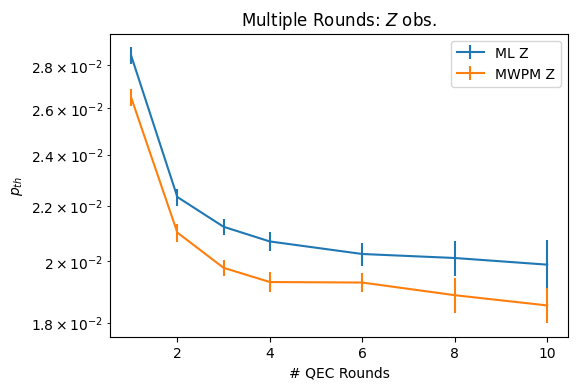

In [34]:
results = [results_ML_Z, results_MWPM_Z, ]
names = ["ML Z", "MWPM Z", ]

plt.figure()
cm = 1/2.54 # to convert inches to cm
plt.subplots(figsize=(15*cm,10*cm))
plt.title("Multiple Rounds: $Z$ obs.")
for i in range(len(results)): 
    p_th = results[i]["p_th"]
    err_p_th = results[i]["err_p_th"]
    plt.errorbar(qec_rounds, p_th, yerr=err_p_th,label=names[i])
plt.xlabel("# QEC Rounds")
plt.ylabel("$p_{th}$")
plt.legend()
plt.yscale("log")
plt.savefig(PATH_TO_IMAGE_FOLDER+"/"+ "multi_round_Z_obs_log"+".pdf") 
plt.show()

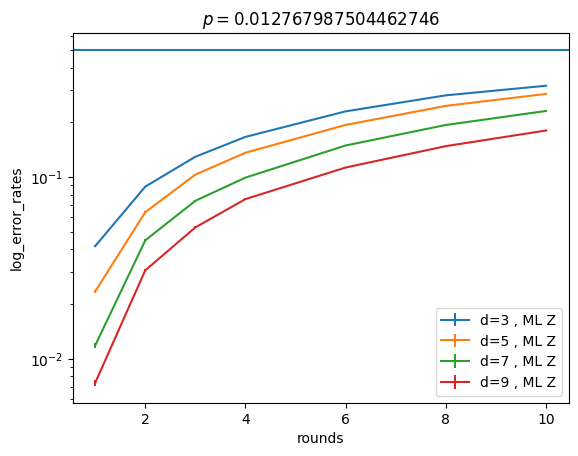

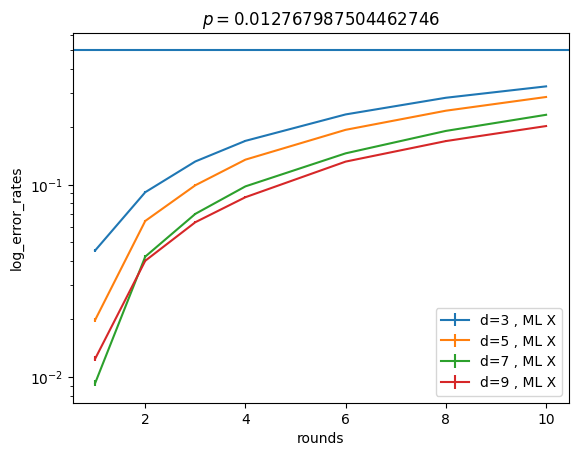

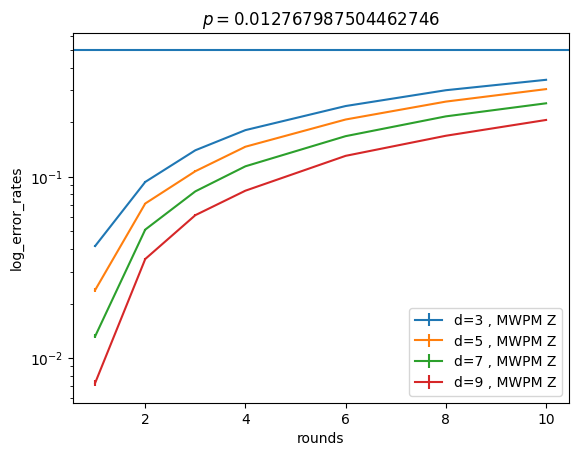

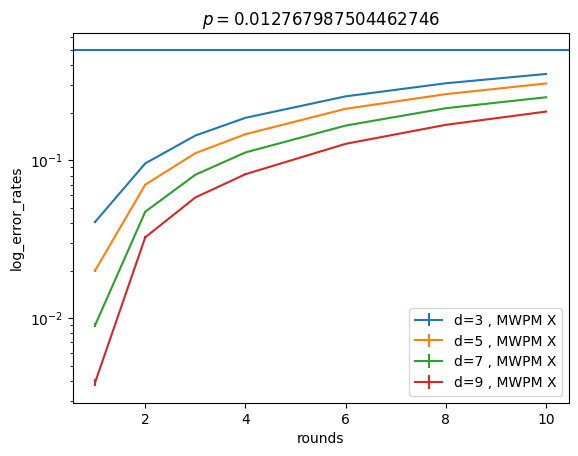

In [18]:
# absolute log_errors
i_noise_rate  = 15

plt.figure()
for j in range(len(results)):
    distances = results[j]["distances"]
    rounds = results[j]["rounds"]
    log_error_rates = results[j]["log_error_rates"]
    err_log_error_rates = results[j]["err_log_error_rates"]

    plt.title(f"$p={results[0]["noise_rates"][i_noise_rate]}$")
    for i in range(len(distances)):
        plt.errorbar(
            rounds,
            log_error_rates[i,:,i_noise_rate],
            yerr=err_log_error_rates[i,:,i_noise_rate], 
            label=f"d={distances[i]} , {names[j]}",
            )
    
    
    plt.legend()
    plt.yscale("log")
    plt.xlabel("rounds")
    plt.ylabel("log_error_rates")
    plt.axhline(0.5,label="log. error rate = 50%")
    plt.show()


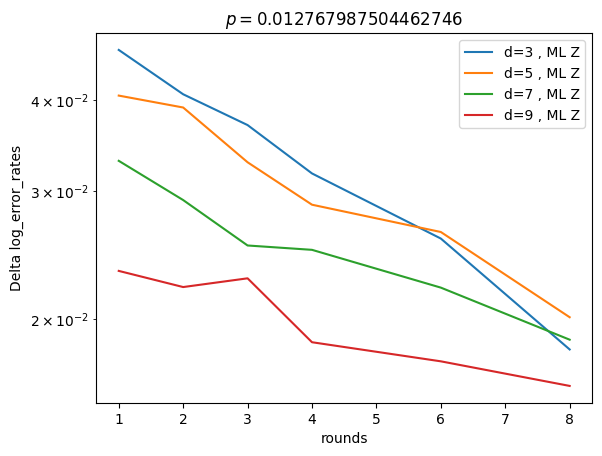

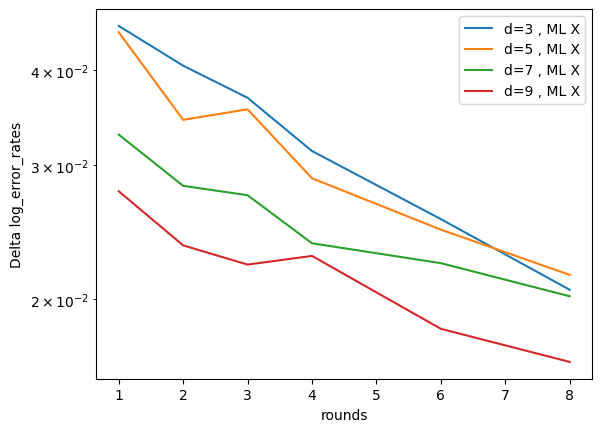

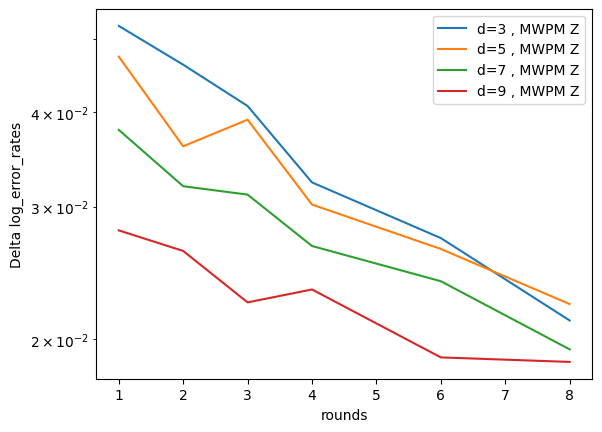

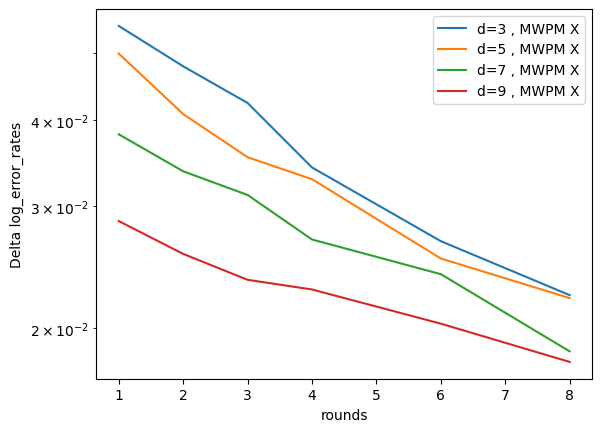

In [19]:
# Delta log_errors
i_noise_rate  = 15
plt.figure()
plt.title(f"$p={results[0]["noise_rates"][i_noise_rate]}$")
for j in range(len(results)):
    distances = results[j]["distances"]
    rounds = results[j]["rounds"]
    log_error_rates = results[j]["log_error_rates"]
    err_log_error_rates = results[j]["err_log_error_rates"]

    for i in range(len(distances)):
        y = (log_error_rates[i,1:,i_noise_rate] - log_error_rates[i,:-1,i_noise_rate])/(rounds[1:]-rounds[:-1])
        plt.errorbar(
            rounds[:-1],
            y, 
            label=f"d={distances[i]} , {names[j]}",
            )
    
    plt.legend()
    plt.yscale("log")
    plt.xlabel("rounds")
    plt.ylabel("Delta log_error_rates")
    plt.show()